# Model Training 

In [1]:
# add project root to the path
import sys
sys.path.append("../")

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from notebooks import *

## 1. Load prepared data and preprocessor

In [4]:
# load saved preprocessor, train/test splits, feature list and scaled data
# Relative paths (industry-standard structure)
with open("../artifacts/models/preprocessor_for_encoding.pkl", "rb") as f:
    preprocessor_for_encoding = pickle.load(f)

data = np.load("../artifacts/splits/x_y_splits.npz")
X_train_prep = data['X_train_prep']
X_test_prep = data['X_test_prep']
y_train = data['y_train']
y_test = data['y_test']


with open("../artifacts/features/categorical_cols.json", "r") as f:
    categorical_cols_clean = json.load(f)

scaled_data_X_train = pd.read_csv("../data/processed/scaled_data_X_train.csv")
scaled_data_X_test = pd.read_csv("../data/processed/scaled_data_X_test.csv")

Accuracy (baseline sanity check only)
> - **What it is:** % of predictions that were correct overall (`correct / total`).
> - **Why we use it here:** Only as a *quick* first-pass comparison across algorithms — it's not trustworthy on its own for this data since defaults are the minority class (a model predicting "no default" for everyone would still score high).
> - **What we achieved:** CatBoost (0.9365) and XGBoost (0.9325) topped the accuracy table, but this number alone is **not** what decided the final model — we need to see the F1/PR-AUC/business-cost sections below for the real selection criteria.


## 2. Baseline model comparison (kept for reference — not used for final selection)

Accuracy is shown here only as a quick sanity check across algorithms. It is **not** the metric used to pick the final model, since the target is imbalanced (~22% default rate).

In [5]:
# Accuracy (baseline sanity check only, NOT the final selection metric)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

def baseline_comparison(X_train, X_test, y_train, y_test, models):
    names, scores = [], []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = accuracy_score(y_test, y_pred)
        names.append(name)
        scores.append(score)
    report = pd.DataFrame({"Model_Name": names, "Accuracy": scores})
    return report.sort_values(by="Accuracy", ascending=False)

baseline_comparison(X_train_prep, X_test_prep, y_train, y_test, models)


,Model_Name,Accuracy
7,CatBoost,0.936504
6,XGBoost,0.932519
1,Random Forest,0.931877
3,Gradient Boosting,0.928021
2,AdaBoost,0.890103
5,Decision Tree,0.881620
0,Logistic Regression,0.842545
4,KNN,0.821337


## 3. Class weight reference (Informative)

In [6]:
# compute balanced class weights for the imbalanced target
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Reference balanced class weights: {class_weight_dict}")


Reference balanced class weights: {0: np.float64(0.6399661542800733), 1: np.float64(2.2861460957178843)}


F1-score as the grid-search objective
> - **What it is:** The harmonic mean of Precision and Recall — `2 × (P×R)/(P+R)`. Unlike accuracy, it punishes a model that ignores the minority class.
> - **Why we use it:** Loan default is imbalanced (far more "No Default" than "Default"), so optimizing for accuracy would just favor the majority class. F1 forces the tuned model to actually catch defaulters without over-predicting them.

## 4. Final model — GridSearchCV-tuned Random Forest
## Random Forest classfier model training with GridSearchCV tuning with Threshold table
Grid search optimizes F1 (better than accuracy for imbalanced data) and searches `class_weight` as a hyperparameter, so this supersedes the earlier manual class-weight and RandomizedSearch attempts.

Confusion matrix, Precision & Recall, and threshold tuning
> - **What it is:** The confusion matrix breaks predictions into TP/FP/FN/TN. **Precision** = of predicted defaulters, how many really defaulted (`TP/(TP+FP)`). **Recall** = of actual defaulters, how many we caught (`TP/(TP+FN)`). The classification **threshold** is the probability cutoff (default 0.5) that turns a predicted probability into a Yes/No — moving it trades recall for precision.
> - **Why we use it:** In credit risk, missing a real defaulter (low recall) is usually costlier than a false alarm, so we don't just accept the default 0.5 threshold — we scan a table of thresholds to find a better recall/precision balance.

In [7]:
# Confusion matrix, Precision, Recall & threshold tuning
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, recall_score, precision_score, f1_score
)

def evaluate_model_with_threshold(model, X_test, y_test, model_name="model", tune=False,
                                   display_labels=['No Default', 'Default'], show_threshold_table=False):

    if tune:
        model = model.best_estimator_

    # get predicted probabilities for positive class
    y_proba = model.predict_proba(X_test)[:, 1]

    # threshold search to find best accuracy
    thresholds = np.arange(0.1, 0.91, 0.01)
    best_thresh = 0.5
    best_acc = 0

    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        acc_t = accuracy_score(y_test, y_pred_t)
        if acc_t > best_acc:
            best_acc = acc_t
            best_thresh = t

    print(f"Best Threshold: {best_thresh:.2f}")
    print(f"Best Accuracy: {best_acc:.4f}")

    # final predictions using best threshold
    y_pred = (y_proba >= best_thresh).astype(int)

    acc = accuracy_score(y_test, y_pred)
    clf_report = classification_report(y_test, y_pred)
    print("Accuracy:", acc)
    print("\nClassification Report:\n", clf_report)


    cm = confusion_matrix(y_test, y_pred)
    if not show_threshold_table:
        
        # display via ConfusionMatrixDisplay (not raw array print) with dynamic title
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
        disp.plot(cmap='Blues')
        plt.title(f'Confusion Matrix — {model_name} (threshold {best_thresh:.2f})')
        plt.show()

    # threshold-wise recall/precision/f1 table
    if show_threshold_table:
        report_thresholds = np.arange(0.1, 0.99, 0.03).round(2)
        print(f"\n{'Threshold':>9} | {'Recall':>6} | {'Precision':>9} | {'F1-Score':>8}")
        print("-" * 50)
        for t in report_thresholds:
            y_pred_t = (y_proba >= t).astype(int)
            recall = recall_score(y_test, y_pred_t)
            precision = precision_score(y_test, y_pred_t, zero_division=0)
            f1 = f1_score(y_test, y_pred_t)
            print(f"{t:>9} | {recall:>6.2f} | {precision:>9.2f} | {f1:>8.2f}")

    return model, acc, clf_report, cm, best_thresh

In [8]:
# function to display confusion matrix and metrics at a given threshold
def show_confusion_matrix_from_prediction(model, X_test, y_test, model_name="model",
                                          display_labels=['No Default', 'Default'], threshold=0.5):

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

        
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=display_labels, cmap='Blues'
    )
    plt.title(f'Confusion Matrix — {model_name} (threshold {threshold:.2f})')
    plt.show()
    return disp, y_pred

In [9]:
# F1-score as the GridSearchCV tuning objective
def rf_grid_search(X_train, y_train):
    param_grid = {
        'n_estimators': [150, 300, 450],
        'max_depth': [10, 20, 30],
        'min_samples_split': [2, 5, 8],
        'min_samples_leaf': [1, 2, 3, 4],
        'max_features': ['sqrt', 'log2'],
        'class_weight': [{0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 4}],
    }
    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(
        estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='f1', verbose=1
    )
    grid_search.fit(X_train, y_train)
    print("Best Params:", grid_search.best_params_)
    print("Best CV F1 Score:", grid_search.best_score_)
    return grid_search


In [10]:
# run grid search for random forest and evaluate the tuned model
rf_grid_search_result = rf_grid_search(
    X_train_prep, 
    y_train)
rf_tuned_model, rf_best_acc, rf_best_clf_report, rf_best_cm, rf_best_thresh = evaluate_model_with_threshold(
    rf_grid_search_result, 
    scaled_data_X_test, 
    y_test, 
    "Random Forest classifier", 
    tune=True,
    show_threshold_table=True
)

Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best Params: {'class_weight': {0: 1, 1: 2}, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 450}
Best CV F1 Score: 0.815500372040308
Best Threshold: 0.54
Best Accuracy: 0.9324
Accuracy: 0.9323907455012853

Classification Report:
               precision    recall  f1-score   support

       False       0.93      0.99      0.96      6079
        True       0.97      0.71      0.82      1701

    accuracy                           0.93      7780
   macro avg       0.95      0.85      0.89      7780
weighted avg       0.93      0.93      0.93      7780


Threshold | Recall | Precision | F1-Score
--------------------------------------------------
      0.1 |   0.95 |      0.40 |     0.56
     0.13 |   0.91 |      0.46 |     0.61
     0.16 |   0.88 |      0.53 |     0.67
     0.19 |   0.85 |      0.60 |     0.70
     0.22 |   0.83 |      0.67 |     0.74
     0.25 |   0.81 

## 4.2 Confusion matrix based on custom balanced threshold to reduce recall case

Accuracy: 0.9113110539845758
              precision    recall  f1-score   support

       False       0.94      0.95      0.94      6079
        True       0.80      0.79      0.80      1701

    accuracy                           0.91      7780
   macro avg       0.87      0.87      0.87      7780
weighted avg       0.91      0.91      0.91      7780



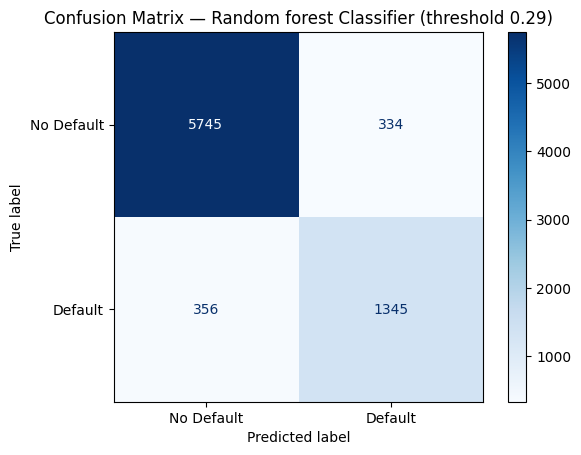

In [34]:
# show confusion matrix for the tuned model at the chosen threshold
_, rf_y_preds = show_confusion_matrix_from_prediction(
    rf_tuned_model,
    X_test_prep,
    y_test,
    "Random forest Classifier",
    threshold=0.29)

#### Check for Data Leakage

In [35]:
# function to check for a large train/test accuracy gap (possible leakage)
def check_leakage(model, X_train, y_train, X_test, y_test, threshold=0.05):
    print("\n" + 3*"#", model, 3*"#" + "/n")
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test, model.predict(X_test))
    gap = train_acc - test_acc

    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Gap:            {gap:.4f}")

    if gap > threshold:
        print("WARNING: Large train-test gap — possible DATA LEAKAGE or overfitting!")
    else:
        print("Gap is small — model looks safe, no obvious leakage.")
        

In [36]:
# run leakage check on the tuned random forest model
check_leakage(rf_tuned_model, X_train_prep, y_train, X_test_prep, y_test)


### RandomForestClassifier(class_weight={0: 1, 1: 2}, max_depth=20,
                       min_samples_split=5, n_estimators=450, random_state=42) ###/n
Train Accuracy: 0.9780
Test Accuracy:  0.9315
Gap:            0.0465
Gap is small — model looks safe, no obvious leakage.


Business cost (turning FN/FP into ₹)
> - **What it is:** Instead of a generic ML metric, this assigns a real rupee cost to each error type from the confusion matrix — a missed defaulter (FN) costs `fn_cost`, a wrongly rejected good customer (FP) costs `fp_cost` — and sums them.
> - **Why we use it:** Precision/recall tell you *how many* errors happen, not *how much they cost the business* — FN and FP are rarely equally expensive in lending, so this ties the model choice back to an actual financial number.

## 5. Business cost (FIXED — now uses actual confusion-matrix counts, not a hardcoded literal)

In [37]:
# Business cost (turning FN/FP into rupees)
def calculate_business_cost(model, X_test, y_test, model_name="model", threshold=0.5, fn_cost=378, fp_cost=316):
    """Calculates total business loss based on FN/FP misclassification costs at a given threshold."""

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total_cost = (fn * fn_cost) + (fp * fp_cost)

    print(f"--- {model_name} (threshold {threshold:.2f}) ---")
    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"Total Business Loss: Rs. {total_cost}")
    print()

    return total_cost

In [38]:
# calculate business cost for the tuned random forest model
rf_total_cost = calculate_business_cost(rf_tuned_model, X_test_prep, y_test, model_name='Random Forest Classifier', threshold=0.31)
print(f"Total cost for Random Forest Classifier: {rf_total_cost}")

--- Random Forest Classifier (threshold 0.31) ---
TN=5802, FP=277, FN=380, TP=1321
Total Business Loss: Rs. 231172

Total cost for Random Forest Classifier: 231172


ROC-AUC & Brier score
> - **What it is:** **ROC-AUC** measures how well the model ranks a random defaulter above a random non-defaulter across *all* thresholds (1.0 = perfect, 0.5 = random guessing). **Brier score** measures how well-calibrated the predicted probabilities are — the mean squared error between predicted probability and actual outcome (lower is better).
> - **Why we use it:** ROC-AUC checks the model's overall discriminative power independent of any one threshold; Brier score checks whether "0.8 probability of default" really behaves like an 80% chance in practice — both matter for a score that will be used for real lending decisions.

## 6. ROC-AUC / Brier score / Precision-Recall curve

In [39]:
# ROC-AUC & Brier score
def evaluate_probability_metrics(model, X_test, y_test, model_name="model"):

    y_proba = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    brier_score = brier_score_loss(y_test, y_proba)

    print(f"--- {model_name} ---")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print(f"Brier Score Loss: {brier_score:.4f} (lower is better)")
    print()

    return roc_auc, brier_score

In [40]:
# evaluate ROC-AUC and Brier score for the tuned random forest model
print(f"--- Random Forest Classifier ---")
rf_roc_curve, rf_brier_score = evaluate_probability_metrics(rf_tuned_model, X_test_prep, y_test, model_name="Random Forest Classifier")

--- Random Forest Classifier ---


--- Random Forest Classifier ---
ROC AUC Score: 0.9352
Brier Score Loss: 0.0597 (lower is better)



In [41]:
# function to plot ROC curve and calibration curve side by side
def plot_roc_and_calibration(model, X_test, y_test, model_name="model"):
    """Plots ROC curve and calibration curve side-by-side for a given model."""

    y_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"roc_auc score of {model_name} : {roc_auc}")
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax[0].plot(fpr, tpr, color='blue', label=f'Model (AUC = {roc_auc:.2f})')
    ax[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
    ax[0].set_xlabel('False Positive Rate'); ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title(f'ROC Curve — {model_name}'); ax[0].legend(); ax[0].grid(True)

    # calibration curve
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
    ax[1].plot(prob_pred, prob_true, marker='o', label=model_name)
    ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
    ax[1].set_xlabel('Mean predicted probability'); ax[1].set_ylabel('Fraction of positives')
    ax[1].set_title(f'Calibration Curve — {model_name}'); ax[1].legend(); ax[1].grid(True)

    plt.tight_layout()
    plt.show()

    return roc_auc

roc_auc score of Random Forest Classifier : 0.9351799387623994


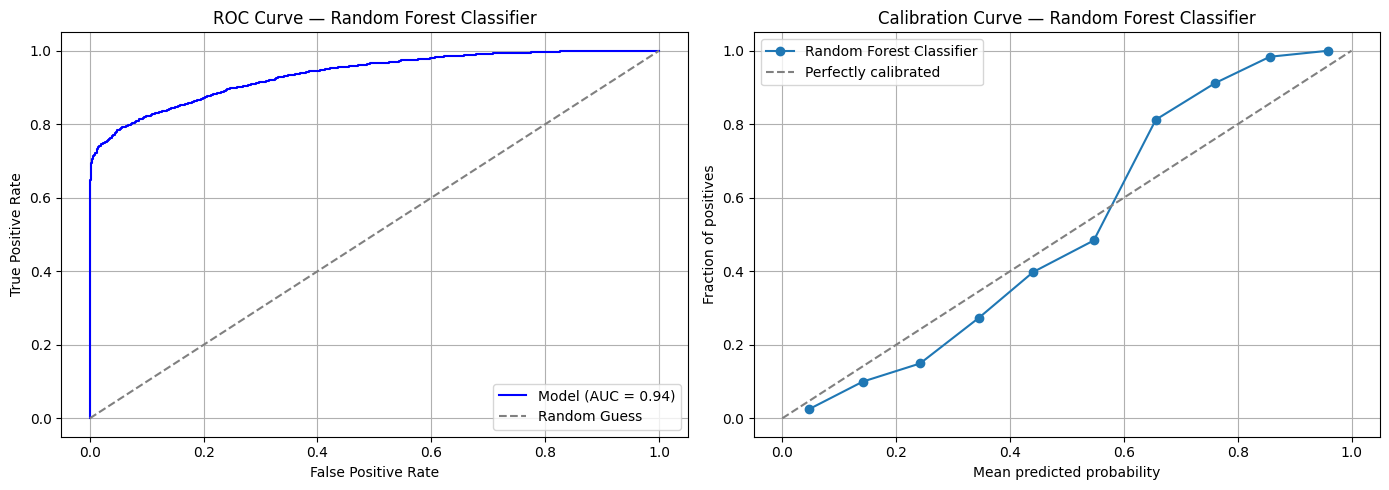

In [42]:
# plot ROC and calibration curves for the tuned random forest model
rf_roc_auc = plot_roc_and_calibration(rf_tuned_model, X_test_prep, y_test, model_name="Random Forest Classifier")

PR-AUC (Precision-Recall AUC)
> - **What it is:** The area under the Precision-Recall curve — unlike ROC-AUC, it focuses only on how well the model handles the *positive* (minority, default) class as the threshold varies.
> - **Why we use it:** ROC-AUC can look overly optimistic on imbalanced data because it also credits performance on the large majority class. PR-AUC is the more honest metric here since we specifically care about correctly catching the minority "Default" cases.

#### PR-AUC Score

In [43]:
# PR-AUC (Precision-Recall AUC)
def calculate_pr_auc(model, X_test, y_test, model_name="model"):
    """Calculates Precision-Recall AUC score."""

    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    print(f"--- {model_name} ---")
    print(f"PR-AUC Score: {pr_auc:.4f}")
    print()

    return pr_auc

In [44]:
# calculate PR-AUC for the tuned random forest model
rf_pr_auc = calculate_pr_auc(rf_tuned_model, X_test_prep, y_test, model_name="Random Forest Classifier")

--- Random Forest Classifier ---
PR-AUC Score: 0.8872



#### Ideal vs Typical PR curve

In [45]:
# function to plot the model's precision-recall curve against a synthetic ideal curve
def plot_pr_curve_vs_ideal(model, X_test, y_test, model_name="model"):
    """Plots the model's Precision-Recall curve against a synthetic 'ideal' curve using Plotly."""

    y_proba = model.predict_proba(X_test)[:, 1]

    # model's actual curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    thresholds_padded = np.append(thresholds, thresholds[-1])  # length match karne ke liye

    # fake/synthetic "ideal" curve
    recall_ideal = np.linspace(0, 1, 100)
    precision_ideal = np.where(recall_ideal < 0.7,
                                1 - 0.05 * recall_ideal,
                                1 - 0.05 * 0.7 - 1.5 * (recall_ideal - 0.7))
    precision_ideal = np.clip(precision_ideal, 0, 1)

    # plots
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=recall, y=precision, mode='lines+markers',
        name=model_name,
        line=dict(color='#2a78d6', width=2),
        marker=dict(size=4),
        customdata=thresholds_padded,
        hovertemplate='Recall: %{x:.2f}<br>Precision: %{y:.2f}<br>Threshold: %{customdata:.2f}<extra>' + model_name + '</extra>'
    ))

    # ideal curve
    fig.add_trace(go.Scatter(
        x=recall_ideal, y=precision_ideal, mode='lines',
        name='Ideal (synthetic)',
        line=dict(color='green', width=2.5),
        hovertemplate='Recall: %{x:.2f}<br>Precision: %{y:.2f}<extra>Ideal</extra>'
    ))

    fig.update_layout(
        title=f'Precision-Recall Curve: {model_name} vs Ideal',
        xaxis_title='Recall',
        yaxis_title='Precision',
        xaxis=dict(range=[0, 1]),
        yaxis=dict(range=[0, 1]),
        template='plotly_white',
        legend=dict(x=0.02, y=0.05)
    )

    fig.show()

    return fig

In [46]:
# plot precision-recall curve for the tuned random forest model
_ = plot_pr_curve_vs_ideal(rf_tuned_model, X_test_prep, y_test, model_name="Random Forest Classifier")

## 7. Top-K high-risk customers

In [47]:
# function to get the top-N highest-risk customers by predicted probability
def get_top_risk_customers(model, X_test, y_test, top_n=20, model_name="model"):
    """Returns a DataFrame of the top-N highest-risk customers sorted by predicted probability."""

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    df_precision_k = pd.DataFrame({
        'actual': y_test,
        'pred_class': y_pred,
        'pred_prob': y_proba,
    }).sort_values(by='pred_prob', ascending=False).reset_index(drop=True)

    print(f"--- {model_name} ---")
    print(f"Top {top_n} highest-risk customers:")

    print(df_precision_k.head(top_n))
    
    return df_precision_k.head(top_n)

In [48]:
# get top 20 highest-risk customers from the test set
rf_model_df_top_k_risky_customers = get_top_risk_customers(rf_tuned_model, 
                                                           X_test_prep, 
                                                           y_test, 
                                                           top_n=20, 
                                                           model_name="Random Forest Classifier")

--- Random Forest Classifier ---
Top 20 highest-risk customers:
    actual  pred_class  pred_prob
0     True        True   0.999237
1     True        True   0.999205
2     True        True   0.998810
3     True        True   0.998519
4     True        True   0.997936
5     True        True   0.997691
6     True        True   0.997576
7     True        True   0.997531
8     True        True   0.997333
9     True        True   0.997333
10    True        True   0.997150
11    True        True   0.997079
12    True        True   0.997030
13    True        True   0.996889
14    True        True   0.996825
15    True        True   0.996667
16    True        True   0.996587
17    True        True   0.996574
18    True        True   0.996481
19    True        True   0.996434


All risky customers without any mistake are predicted defaulters correctly

SHAP feature explanation
> - **What it is:** SHAP (SHapley Additive exPlanations) breaks a single prediction into per-feature contributions — how much each feature pushed the predicted probability up or down for one specific customer.
> - **Why we use it:** A credit decision needs to be explainable (to the customer and to regulators) — "the model said no" isn't enough, we need to show *which* factors drove that specific score.

## 8. SHAP feature explanation 

In [49]:
# SHAP feature explanation
def explain_rows_with_shap(model, preprocessor, rows_dict, scaled_data_X_train, threshold=0.05):
    feature_names = scaled_data_X_train.columns
    explainer = shap.TreeExplainer(model)
    for label, raw_row in rows_dict.items():
        row_df = pd.DataFrame([raw_row])
        row_prep = preprocessor.transform(row_df)
        proba = model.predict_proba(row_prep)[:, 1][0]
        decision = "Default" if proba >= threshold else "No Default"
        print(f"{label}: probability={proba:.3f} -> {decision}")
        shap_values = explainer.shap_values(row_prep)
        
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        elif shap_values.ndim == 3:
            shap_values = shap_values[:, :, 1]   # (1, 27, 2) -> (1, 27), class 1 (Default)

        shap.summary_plot(shap_values, row_prep, feature_names=feature_names, plot_type='bar', max_display=len(feature_names), show=False)

        fig = plt.gcf()
        fig.set_size_inches(10, 12)
        plt.tight_layout()
        plt.show()


example_customer: probability=0.126 -> No Default


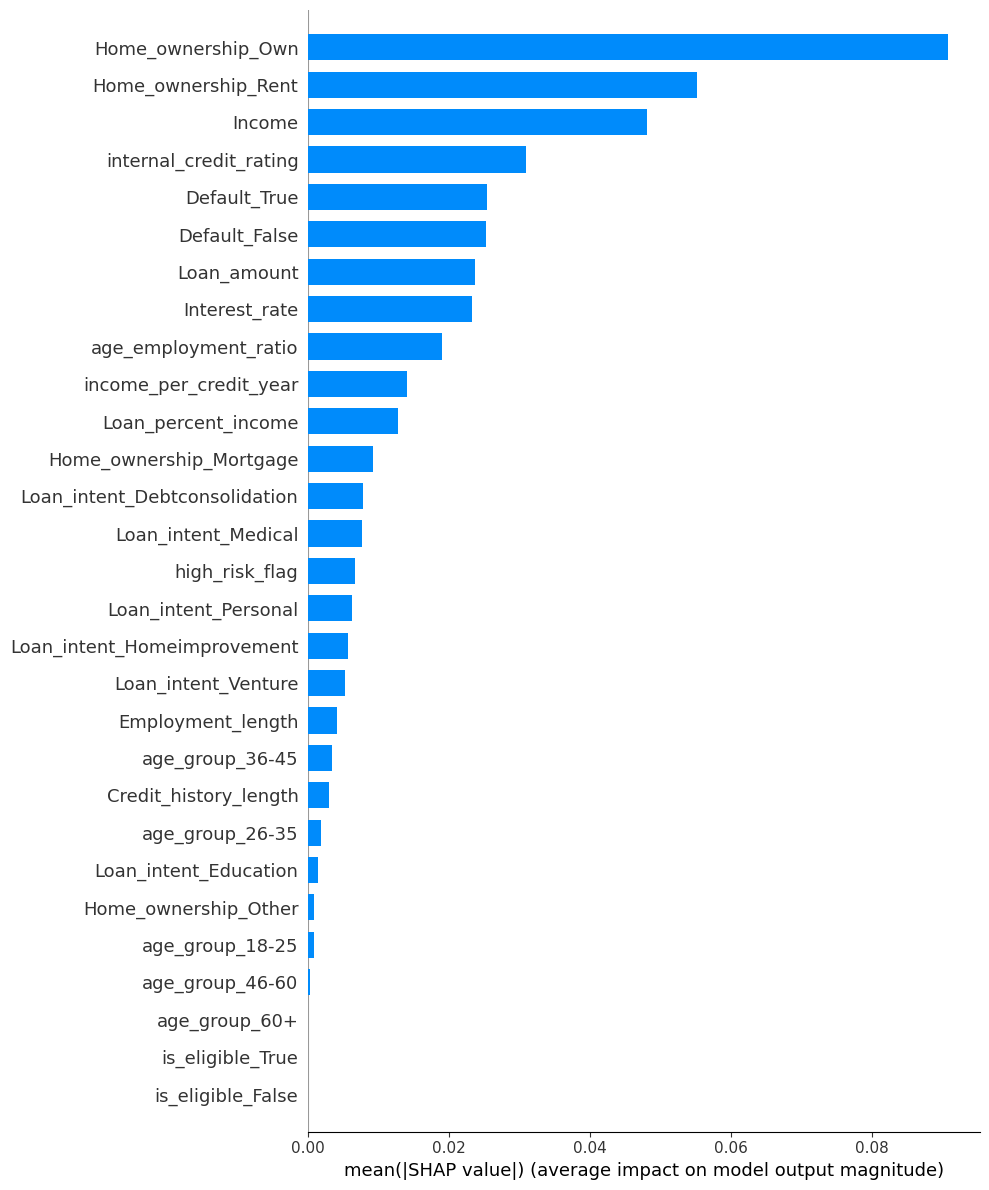

In [50]:
# define an example customer and explain their prediction with SHAP
example_customer = {
    "Income": 420000,
    "Home_ownership": "Own",
    "Employment_length": 3,
    "Loan_intent": "Personal",
    "internal_credit_rating": 5,
    "Loan_amount": 120000,
    "Interest_rate": 9.5,
    "Loan_percent_income": 0.28,
    "Default": True,
    "Credit_history_length": 5,
    "credit_score": 785.120,
    "age_group": "36-45",
    "is_eligible": True,
    "high_risk_flag": False,
    "age_employment_ratio": 13.33,
    "income_per_credit_year": 84000
}

explain_rows_with_shap(rf_tuned_model, preprocessor_for_encoding, {
    "example_customer": example_customer}, 
    scaled_data_X_train, 
    threshold=0.28)


Feature importance
> - **What it is:** Random Forest's built-in ranking of how much each feature reduced impurity across all trees — a *global* (whole-model) view, unlike SHAP which explains one prediction at a time.
> - **Why we use it:** Useful for a high-level sanity check — confirming the model is leaning on sensible risk drivers rather than spurious columns — and for reporting to stakeholders which factors matter most overall.

## 9. Feature importance

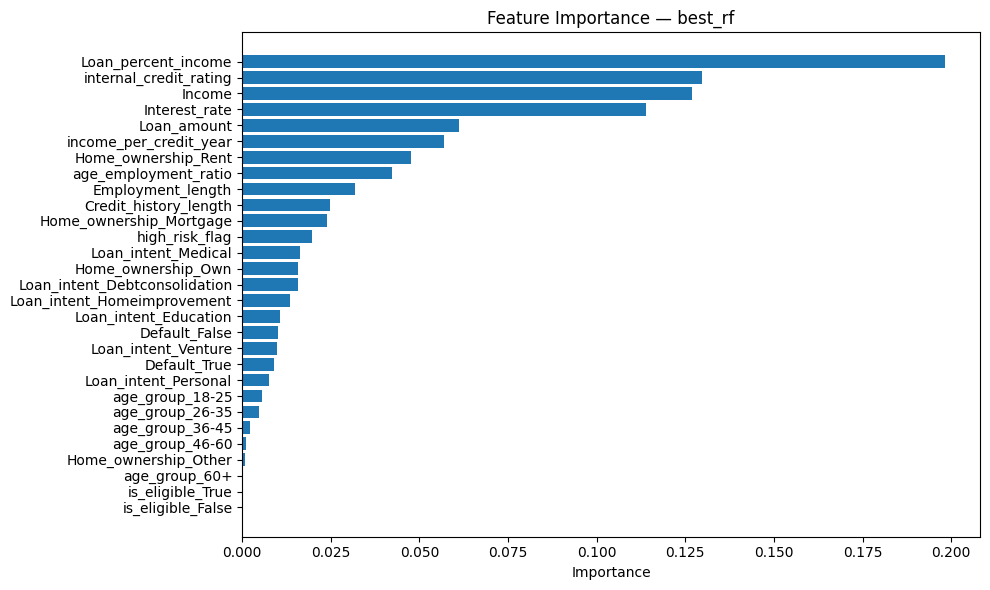

In [51]:
# Feature importance (whole-model view)
feat_imp = pd.DataFrame({
    "feature": scaled_data_X_train.columns,
    "importance": rf_tuned_model.feature_importances_,
}).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.xlabel("Importance")
plt.title("Feature Importance — best_rf")
plt.tight_layout()
plt.show()


In [52]:
# save model predictions to disk
np.savez("../artifacts/predictions/prediction",
        rf_y_preds=rf_y_preds)
print("Saved predictions to ../artifacts/predictions/prediction.npy")


Saved predictions to ../artifacts/predictions/prediction.npy


In [53]:
# function to flag high-risk customers using simple business rules
def rule_based_risk_flag(customer: dict):
    """Flags a customer as high-risk based on top-5 SHAP-important features using business rules."""

    flags = []

    # Rule 1: Loan_percent_income too high (loan burden relative to income)
    if customer.get("Loan_percent_income", 0) > 0.5:
        flags.append(f"High loan-to-income ratio ({customer['Loan_percent_income']:.2f})")

    # Rule 2: Poor internal credit rating (assuming lower = worse, scale ~1-10)
    if customer.get("internal_credit_rating", 10) <= 4:
        flags.append(f"Low internal credit rating ({customer['internal_credit_rating']})")

    # Rule 3: Low income
    if customer.get("Income", 0) < 20000:
        flags.append(f"Low income (₹{customer['Income']})")

    # Rule 4: High interest rate (indicates lender already sees risk)
    if customer.get("Interest_rate", 0) > 15:
        flags.append(f"High interest rate ({customer['Interest_rate']}%)")

    # Rule 5: Large loan amount
    if customer.get("Loan_amount", 0) > 30000:
        flags.append(f"Large loan amount (₹{customer['Loan_amount']})")

    is_high_risk = len(flags) >= 2  # 2+ red flags → high risk

    print(f"--- Rule-Based Risk Check ---")
    if flags:
        for f in flags:
            print(f"⚠️ {f}")
    else:
        print("✅ No rule violations.")

    print(f"\nFinal Rule-Based Verdict: {'HIGH RISK' if is_high_risk else 'LOW RISK'}")

    return is_high_risk, flags

In [54]:
# run rule-based risk check on the example customer
rule_based_risk_flag(example_customer)

--- Rule-Based Risk Check ---
⚠️ Large loan amount (₹120000)

Final Rule-Based Verdict: LOW RISK


(False, ['Large loan amount (₹120000)'])

## 10. Save final model + metadata (FIXED — versioned artifacts, relative paths, no lone untracked pkl)

In [55]:
def save_model_with_metadata(model, model_type, best_params, threshold,
                              roc_auc, brier_score, pr_auc, total_cost,
                              model_name="final_model", save_dir="../artifacts/models",
                              selection_method="GridSearchCV", scoring="f1"):
    """Saves a trained model as pickle + its metadata as JSON."""

    os.makedirs(save_dir, exist_ok=True)

    model_path = os.path.join(save_dir, f"{model_name}.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)

    metadata = {
        "model_type": model_type,
        "selection_method": selection_method,
        "scoring": scoring,
        "best_params": best_params,
        "final_threshold": threshold,
        "metrics": {
            "roc_auc": round(float(roc_auc), 4),
            "brier_score": round(float(brier_score), 4),
            "pr_auc": round(float(pr_auc), 4),
            "business_cost": int(total_cost),
        },
        "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    }

    metadata_path = os.path.join(save_dir, f"{model_name}_metadata.json")
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Saved {model_name}.pkl and {model_name}_metadata.json")
    print(json.dumps(metadata, indent=2))

    return model_path, metadata_path

In [56]:
# save the final tuned model along with its metadata
save_model_with_metadata(
    model=rf_tuned_model,
    model_type="RandomForestClassifier",
    best_params=rf_grid_search_result.best_params_,
    threshold=0.28,
    roc_auc=rf_roc_auc, brier_score=rf_brier_score, pr_auc=rf_pr_auc, total_cost=rf_total_cost,
    model_name="rf_final_model"
)

Saved rf_final_model.pkl and rf_final_model_metadata.json
{
  "model_type": "RandomForestClassifier",
  "selection_method": "GridSearchCV",
  "scoring": "f1",
  "best_params": {
    "class_weight": {
      "0": 1,
      "1": 2
    },
    "max_depth": 20,
    "max_features": "sqrt",
    "min_samples_leaf": 1,
    "min_samples_split": 5,
    "n_estimators": 450
  },
  "final_threshold": 0.28,
  "metrics": {
    "roc_auc": 0.9352,
    "brier_score": 0.0597,
    "pr_auc": 0.8872,
    "business_cost": 231172
  },
  "trained_at_utc": "2026-09-12T01:20:41.099211+00:00"
}


('../artifacts/models\\rf_final_model.pkl',
 '../artifacts/models\\rf_final_model_metadata.json')